# Модель M/M/c: набор параметров

Десяти заявок мало, чтобы сравнивать модель с теорией, поэтому здесь
моделирование повторяется для 20000 заявок при разном числе каналов
и разной интенсивности входящего потока. Результаты сравниваются
с аналитическими формулами.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(MMcModel) || include(srcdir("MMcModel.jl"))
using .MMcModel
using DataFrames, CSV, Plots, Statistics

script_name = "mmc_params"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab07/project/data"

## Набор параметров

Функция `dict_list` строит все комбинации: 3 значения числа каналов
и 3 значения интенсивности прихода --- всего 9 запусков.

In [2]:
mmc_dict = Dict(
    :c => [2, 3, 4],
    :lam => [0.5, 0.7, 0.9],
    :mu => 0.5,
    :n => 20000,
    :seed => 123,
)

mmc_list = dict_list(mmc_dict)
length(mmc_list)

9

## Функция одного эксперимента

Функция запускает моделирование и возвращает загрузку, среднее время
ожидания и вероятность ожидания: из модели и по формулам.

In [3]:
function run_mmc(p)
    res = simulate_mmc(lam = p[:lam], mu = p[:mu], c = p[:c], n = p[:n], seed = p[:seed])
    th = mmc_analytic(p[:lam], p[:mu], p[:c])
    return (
        c = p[:c],
        lam = p[:lam],
        rho = round(th.rho, digits = 3),
        Wq_sim = round(mean(res.wait), digits = 4),
        Wq_theory = round(th.Wq, digits = 4),
        Pwait_sim = round(mean(res.wait .> 1e-9), digits = 4),
        Pwait_theory = round(th.Pwait, digits = 4),
    )
end

run_mmc (generic function with 1 method)

## Запуск экспериментов

In [4]:
df_mmc = DataFrame([run_mmc(p) for p in mmc_list])
sort!(df_mmc, [:c, :lam])
CSV.write(datadir("mmc_params.csv"), df_mmc)
println(df_mmc)

9×7 DataFrame
 Row │ c      lam      rho      Wq_sim   Wq_theory  Pwait_sim  Pwait_theory 
     │ Int64  Float64  Float64  Float64  Float64    Float64    Float64      
─────┼──────────────────────────────────────────────────────────────────────
   1 │     2      0.5    0.5     0.6758     0.6667     0.3418        0.3333
   2 │     2      0.7    0.7     1.9941     1.9216     0.5905        0.5765
   3 │     2      0.9    0.9     9.4525     8.5263     0.8732        0.8526
   4 │     3      0.5    0.333   0.0883     0.0909     0.0925        0.0909
   5 │     3      0.7    0.467   0.2566     0.2529     0.2129        0.2024
   6 │     3      0.9    0.6     0.618      0.5912     0.3682        0.3547
   7 │     4      0.5    0.25    0.0118     0.0136     0.0186        0.0204
   8 │     4      0.7    0.35    0.0434     0.0464     0.0611        0.0603
   9 │     4      0.9    0.45    0.1137     0.1168     0.1334        0.1285


## Графики

Точки --- результат моделирования, пунктир --- теория.
Слева среднее время ожидания, справа вероятность ожидания.

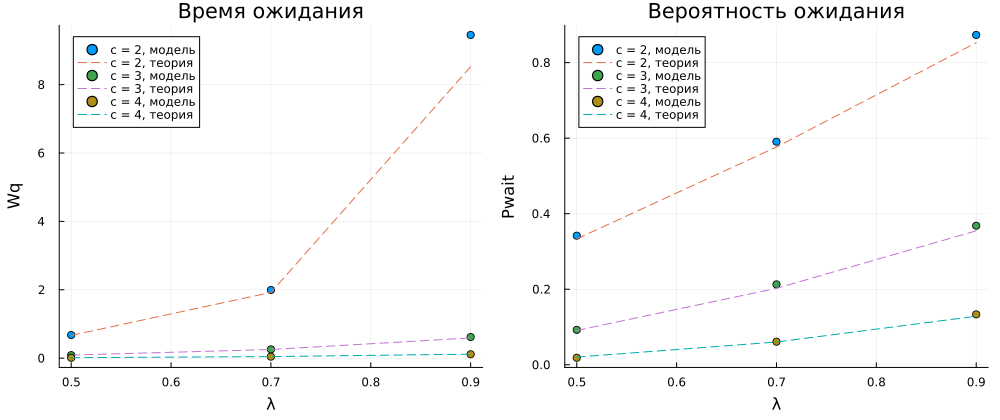

In [5]:
p1 = plot(xlabel = "λ", ylabel = "Wq", title = "Время ожидания", legend = :topleft)
p2 = plot(xlabel = "λ", ylabel = "Pwait", title = "Вероятность ожидания", legend = :topleft)
for c in sort(unique(df_mmc.c))
    part = df_mmc[df_mmc.c .== c, :]
    scatter!(p1, part.lam, part.Wq_sim, label = "c = $c, модель")
    plot!(p1, part.lam, part.Wq_theory, linestyle = :dash, label = "c = $c, теория")
    scatter!(p2, part.lam, part.Pwait_sim, label = "c = $c, модель")
    plot!(p2, part.lam, part.Pwait_theory, linestyle = :dash, label = "c = $c, теория")
end
plt_mmc = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

## Сохранение графика

In [6]:
savefig(plt_mmc, plotsdir("mmc_params.png"))
println("Результаты сохранены в data/mmc_params.csv и plots/mmc_params.png")

Результаты сохранены в data/mmc_params.csv и plots/mmc_params.png
